In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

!pip install -q albumentations timm grad-cam shap torchmetrics

Mounted at /content/gdrive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 115.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 74.4 MB/s eta 0:00:00


Displaying sampled Images and Masks for visualization (Figure width reduced for tighter packing):

Visualization generated with minimal spacing, reduced figure width, and sample titles consolidated.


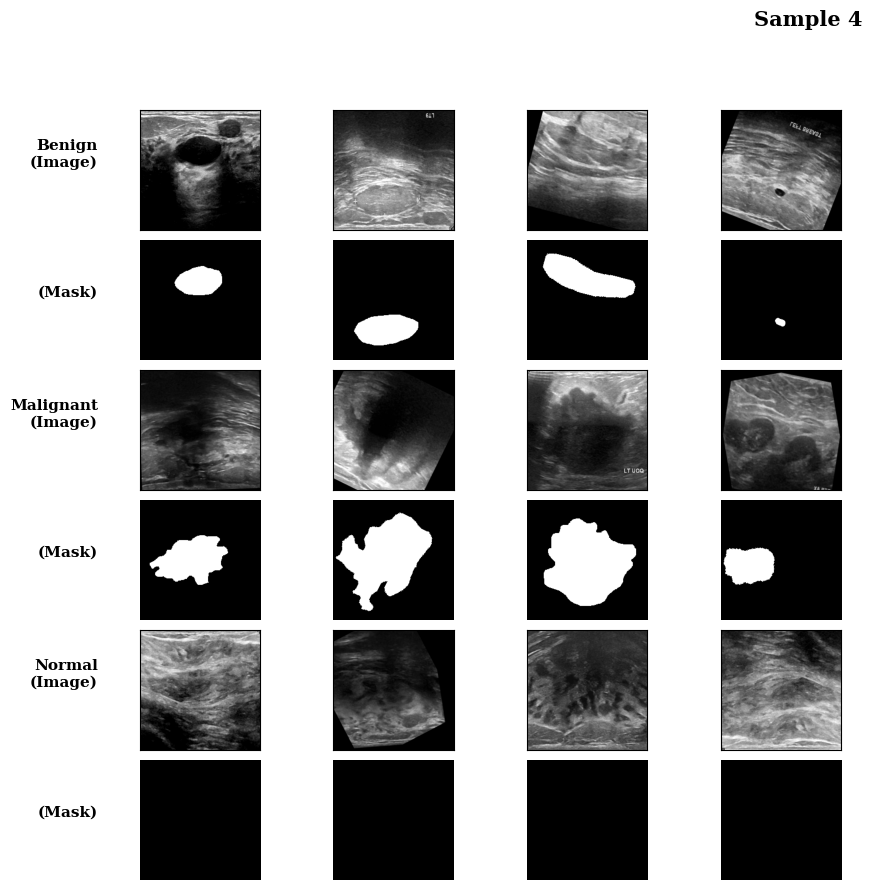

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# --- Configuration ---
processed_root = "/content/gdrive/MyDrive/BUSI_1_project/processed"
img_root = os.path.join(processed_root, "images")
mask_root = os.path.join(processed_root, "masks")
target_samples_per_class = 4
classes = ["benign", "malignant", "normal"]

# --- Font Setting: Change all fonts to Times New Roman ---
# Set the default font family to 'serif' and specify Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
# Also update the math font to match for consistency
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
Y_LABEL_FONTSIZE = 14 # Increased from 11
SUPTITLE_FONTSIZE = 18 # Increased from 15
# -----------------------------------------------------------

# --- Sampling and Visualization ---
# MODIFICATION: Reduced figure width from 22 to 14 to force tighter packing
# MODIFICATION: wspace is kept at 0.0 for minimal gap
fig, axes = plt.subplots(
    len(classes) * 2,
    target_samples_per_class,
    figsize=(10,10),
    gridspec_kw={'wspace': 0.0, 'hspace': 0.08}
)

# Adjust global spacing
plt.subplots_adjust(wspace=0.0, hspace=0.08)

print("Displaying sampled Images and Masks for visualization (Figure width reduced for tighter packing):")

for i, cls in enumerate(classes):

    img_row_start = i * 2
    mask_row_start = i * 2 + 1

    cls_img_path = os.path.join(img_root, cls)
    cls_mask_path = os.path.join(mask_root, cls)

    all_images = [f for f in os.listdir(cls_img_path) if f.endswith('.png')]

    try:
        sampled_images = random.sample(all_images, min(target_samples_per_class, len(all_images)))
    except ValueError as e:
        print(f"Skipping {cls}: Not enough images to sample 4. Error: {e}")
        continue

    for j, img_name in enumerate(sampled_images):
        # --- Image ---
        img_path = os.path.join(cls_img_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not read image: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax_img = axes[img_row_start, j]
        ax_img.imshow(img)
        ax_img.set_xticks([])
        ax_img.set_yticks([])

        if j == 0:
            ax_img.set_ylabel(f"{cls.capitalize()}\n(Image)", rotation=0, labelpad=30, fontsize=11, weight='bold', ha='right')

        # --- Mask ---
        mask_name = img_name.replace('.png', '_mask.png')
        mask_path = os.path.join(cls_mask_path, mask_name)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if mask is None:
            print(f"Could not read mask: {mask_path}")
            continue

        ax_mask = axes[mask_row_start, j]
        ax_mask.imshow(mask, cmap='gray')
        ax_mask.set_xticks([])
        ax_mask.set_yticks([])

        if j == 0:
            ax_mask.set_ylabel("(Mask)", rotation=0, labelpad=30, fontsize=11, weight='bold', ha='right')

        for side in ['top', 'bottom', 'left', 'right']:
            ax_mask.spines[side].set_visible(False)
        ax_mask.tick_params(axis='both', which='both', length=0)

# Re-add Sample titles as Figure SupTitles (above the entire figure) to indicate samples
# This title is less intrusive than individual subplot titles
for j in range(target_samples_per_class):
    # Note: SupTitles will also use Times New Roman now
    fig.suptitle(f"Sample {j+1}", x=(0.17 + j * 0.22), y=0.98, fontsize=15, weight='bold', ha='center')


print("\nVisualization generated with minimal spacing, reduced figure width, and sample titles consolidated.")
plt.show()

In [ ]:
import os
import cv2
import random
import albumentations as A
from tqdm import tqdm
from google.colab import drive

# Mount Drive if not already mounted
# drive.mount('/content/drive')

input_root = "/content/gdrive/MyDrive/BUSI_1_project/raw"
output_root = "/content/gdrive/MyDrive/BUSI_1_project/processed"
os.makedirs(output_root, exist_ok=True)

# Define augmentation pipeline
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=30, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, p=0.3)
])

# Target resize and count
target_size = (224, 224)
target_images_per_class = 3333  # ~10k total across 3 classes

# Iterate over each class folder (benign, malignant, normal)
for cls in os.listdir(os.path.join(input_root, "images")):
    input_img_path = os.path.join(input_root, "images", cls)
    input_mask_path = os.path.join(input_root, "masks", cls)

    output_img_path = os.path.join(output_root, "images", cls)
    output_mask_path = os.path.join(output_root, "masks", cls)
    os.makedirs(output_img_path, exist_ok=True)
    os.makedirs(output_mask_path, exist_ok=True)

    # List of all images for that class
    images = [f for f in os.listdir(input_img_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    count = 0

    print(f"🔄 Processing class: {cls} ...")

    while count < target_images_per_class:
        img_name = random.choice(images)
        img_path = os.path.join(input_img_path, img_name)
        mask_path = os.path.join(input_mask_path, img_name.replace('.png', '_mask.png'))

        # Read image and mask
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # mask is single channel

        if img is None or mask is None:
            print(f"⚠️ Skipping {img_name} due to missing image or mask.")
            continue

        # Resize both
        img = cv2.resize(img, target_size)
        mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

        # Apply same augmentation to both
        augmented = augment(image=img, mask=mask)
        aug_img = augmented['image']
        aug_mask = augmented['mask']

        # Save results
        save_img_name = f"{cls}_{count}.png"
        save_mask_name = f"{cls}_{count}_mask.png"

        cv2.imwrite(os.path.join(output_img_path, save_img_name), aug_img)
        cv2.imwrite(os.path.join(output_mask_path, save_mask_name), aug_mask)

        count += 1

    print(f"✅ Done augmenting class: {cls} ({count} images)")

print("🎉 Preprocessing & augmentation (with masks) complete!")


🔄 Processing class: benign ...
✅ Done augmenting class: benign (3333 images)
🔄 Processing class: malignant ...
✅ Done augmenting class: malignant (3333 images)
🔄 Processing class: normal ...
✅ Done augmenting class: normal (3333 images)
🎉 Preprocessing & augmentation (with masks) complete!


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define paths
processed_root = "/content/gdrive/MyDrive/BUSI_1_project/processed"
base_dir = "/content/gdrive/MyDrive/BUSI_1_project"

# Paths for images and masks
img_root = os.path.join(processed_root, "images")
mask_root = os.path.join(processed_root, "masks")

In [ ]:

# Remove old splits if needed (optional)
!rm -rf /content/drive/MyDrive/BUSI_1_project/train
!rm -rf /content/drive/MyDrive/BUSI_1_project/val
!rm -rf /content/drive/MyDrive/BUSI_1_project/test

In [ ]:
# Create new split folders
splits = ['train', 'val', 'test']
for split in splits:
    for sub in ['images', 'masks']:
        for cls in os.listdir(img_root):
            os.makedirs(os.path.join(base_dir, split, sub, cls), exist_ok=True)

# Split and copy images + masks
for cls in os.listdir(img_root):
    cls_img_path = os.path.join(img_root, cls)
    cls_mask_path = os.path.join(mask_root, cls)

    imgs = [f for f in os.listdir(cls_img_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    if len(imgs) == 0:
        print(f"⚠️ Skipping empty class folder: {cls}")
        continue

    # Split the data (70/15/15)
    train_imgs, temp_imgs = train_test_split(imgs, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    # Copy function for image-mask pairs
    def copy_pairs(file_list, subset_name):
        for img_name in file_list:
            # Derive mask filename (same prefix, _mask suffix)
            mask_name = img_name.replace('.png', '_mask.png')
            img_src = os.path.join(cls_img_path, img_name)
            mask_src = os.path.join(cls_mask_path, mask_name)

            img_dest = os.path.join(base_dir, subset_name, "images", cls, img_name)
            mask_dest = os.path.join(base_dir, subset_name, "masks", cls, mask_name)

            if os.path.exists(mask_src):  # copy only if mask exists
                shutil.copy(img_src, img_dest)
                shutil.copy(mask_src, mask_dest)
            else:
                print(f"⚠️ Mask missing for {img_name}, skipping.")

    # Perform copies
    copy_pairs(train_imgs, "train")
    copy_pairs(val_imgs, "val")
    copy_pairs(test_imgs, "test")

print("✅ Dataset successfully split into train/val/test (images + masks)")

✅ Dataset successfully split into train/val/test (images + masks)


In [ ]:
import os

base_dir = "/content/gdrive/MyDrive/BUSI_1_project"

for subset in ['train', 'val', 'test']:
    print(f"\n{subset.upper()} SET:")

    img_root = os.path.join(base_dir, subset, "images")
    mask_root = os.path.join(base_dir, subset, "masks")

    for cls in os.listdir(img_root):
        cls_img_path = os.path.join(img_root, cls)
        cls_mask_path = os.path.join(mask_root, cls)

        num_imgs = len(os.listdir(cls_img_path)) if os.path.exists(cls_img_path) else 0
        num_masks = len(os.listdir(cls_mask_path)) if os.path.exists(cls_mask_path) else 0

        print(f"  {cls}: {num_imgs} images | {num_masks} masks")



TRAIN SET:
  malignant: 2333 images | 2333 masks
  benign: 2333 images | 2333 masks
  normal: 2333 images | 2333 masks

VAL SET:
  malignant: 500 images | 500 masks
  benign: 500 images | 500 masks
  normal: 500 images | 500 masks

TEST SET:
  malignant: 500 images | 500 masks
  benign: 500 images | 500 masks
  normal: 500 images | 500 masks


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Base directory for your new project
data_dir = "/content/gdrive/MyDrive/BUSI_1_project"

# All images resized to 224×224 (for ResNet101)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets (only from images folders)
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train/images"), transform=transform_train)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val/images"), transform=transform_val_test)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test/images"), transform=transform_val_test)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Summary
print(f"✅ Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}")
print(f"🩺 Classes: {train_dataset.classes}")


✅ Train size: 6999 | Val size: 1500 | Test size: 1500
🩺 Classes: ['benign', 'malignant', 'normal']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

# Load pretrained ResNet101 model
model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)  # Updated for newer torchvision
num_features = model.fc.in_features

# Modify final layer for 3 output classes (benign, malignant, normal)
model.fc = nn.Linear(num_features, 3)

# Move model to device
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

print("✅ ResNet101 model configured for BUSI_1_project (3 classes: benign, malignant, normal)")


🚀 Using device: cuda
✅ ResNet101 model configured for BUSI_1_project (3 classes: benign, malignant, normal)


In [ ]:
import torch
from tqdm import tqdm  # progress bar

num_epochs = 10
best_val_acc = 0.0

# Path to save best model
save_path = "/content/gdrive/MyDrive/BUSI_1_project/models/best_resnet101.pth"

for epoch in range(num_epochs):
    print(f"\n🔹 Epoch [{epoch+1}/{num_epochs}]")
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    # Training loop with progress bar
    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    avg_train_loss = train_loss / total

    # Validation phase
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    print(f"📊 Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"✅ Best model updated & saved at: {save_path}")

print(f"\n🎯 Training complete! Best Validation Accuracy: {best_val_acc:.4f}")



🔹 Epoch [1/10]


📊 Train Loss: 0.3655 | Train Acc: 0.8564 | Val Acc: 0.9393
✅ Best model updated & saved at: /content/gdrive/MyDrive/BUSI_1_project/models/best_resnet101.pth

🔹 Epoch [2/10]


📊 Train Loss: 0.1551 | Train Acc: 0.9446 | Val Acc: 0.9453
✅ Best model updated & saved at: /content/gdrive/MyDrive/BUSI_1_project/models/best_resnet101.pth

🔹 Epoch [3/10]


📊 Train Loss: 0.0998 | Train Acc: 0.9680 | Val Acc: 0.9720
✅ Best model updated & saved at: /content/gdrive/MyDrive/BUSI_1_project/models/best_resnet101.pth

🔹 Epoch [4/10]


📊 Train Loss: 0.0834 | Train Acc: 0.9704 | Val Acc: 0.9660

🔹 Epoch [5/10]


...

📊 Train Loss: 0.0669 | Train Acc: 0.9770 | Val Acc: 0.9727

🔹 Epoch [7/10]


📊 Train Loss: 0.0516 | Train Acc: 0.9820 | Val Acc: 0.9773

🔹 Epoch [8/10]


📊 Train Loss: 0.0634 | Train Acc: 0.9783 | Val Acc: 0.9733

🔹 Epoch [9/10]


📊 Train Loss: 0.0529 | Train Acc: 0.9804 | Val Acc: 0.9847
✅ Best model updated & saved at: /content/gdrive/MyDrive/BUSI_1_project/models/best_resnet101.pth

🔹 Epoch [10/10]


📊 Train Loss: 0.0341 | Train Acc: 0.9863 | Val Acc: 0.9793

🎯 Training complete! Best Validation Accuracy: 0.9847


📊 Classification Report:
              precision    recall  f1-score   support

      benign       0.99      0.96      0.97       500
   malignant       0.98      0.99      0.98       500
      normal       0.98      1.00      0.99       500

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



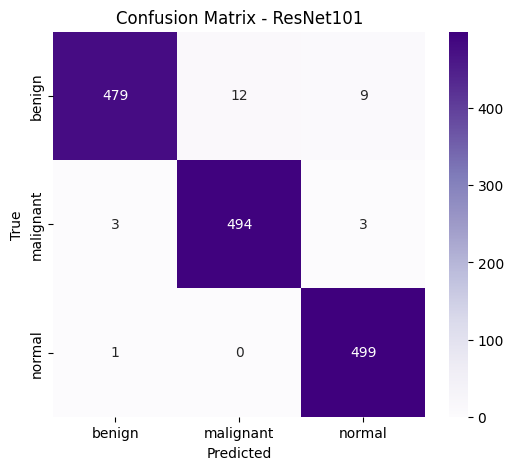

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Load the best saved model
model.load_state_dict(torch.load("/content/gdrive/MyDrive/BUSI_1_project/models/best_resnet101.pth", map_location=device))
model.eval()

y_true, y_pred = [], []

# Evaluate on test set
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Print classification metrics
print("📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.title("Confusion Matrix - ResNet101")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
!pip install -q timm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm, os, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vit = timm.create_model("vit_base_patch16_224", pretrained=True)
vit.head = nn.Linear(vit.head.in_features, 3)
vit = vit.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit.parameters(), lr=1e-4)


In [ ]:
num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):
    vit.train()
    running_corrects, total = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = vit(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        _, preds = torch.max(out, 1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)
    train_acc = running_corrects / total

    vit.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = vit(imgs)
            _, preds = torch.max(out, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(vit.state_dict(), "/content/gdrive/MyDrive/BUSI_1_project/best_vit.pth")
        print("✅ Saved best ViT model.")


In [ ]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from torch import nn, optim
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
data_dir = "/content/gdrive/MyDrive/BUSI_1_project"
train_path = os.path.join(data_dir, "train/images")
val_path   = os.path.join(data_dir, "val/images")
test_path  = os.path.join(data_dir, "test/images")
best_model_path = os.path.join(data_dir, "best_vit.pth")

# Transforms
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Datasets
train_ds = datasets.ImageFolder(train_path, transform=transform_train)
val_ds   = datasets.ImageFolder(val_path, transform=transform_eval)
test_ds  = datasets.ImageFolder(test_path, transform=transform_eval)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(f"Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)} | Classes={train_ds.classes}")


Train=6999 | Val=1500 | Test=1500 | Classes=['benign', 'malignant', 'normal']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ViT model
vit = timm.create_model("vit_base_patch16_224", pretrained=True)
vit.head = nn.Linear(vit.head.in_features, len(train_ds.classes))  # Automatically match num classes
vit = vit.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit.parameters(), lr=1e-4)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):
    # --- Training ---
    vit.train()
    running_corrects, total = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = vit(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(out, 1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = running_corrects / total

    # --- Validation ---
    vit.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = vit(imgs)
            _, preds = torch.max(out, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(vit.state_dict(), best_model_path)
        print("✅ Saved best ViT model.")


Epoch 1/10 | Train Acc=0.6325 | Val Acc=0.8113
✅ Saved best ViT model.
Epoch 2/10 | Train Acc=0.8767 | Val Acc=0.9213
✅ Saved best ViT model.
Epoch 3/10 | Train Acc=0.9253 | Val Acc=0.9447
✅ Saved best ViT model.
Epoch 4/10 | Train Acc=0.9434 | Val Acc=0.9580
✅ Saved best ViT model.
Epoch 5/10 | Train Acc=0.9660 | Val Acc=0.9727
✅ Saved best ViT model.
Epoch 6/10 | Train Acc=0.9680 | Val Acc=0.9667
Epoch 7/10 | Train Acc=0.9624 | Val Acc=0.9480
Epoch 8/10 | Train Acc=0.9700 | Val Acc=0.9493
Epoch 9/10 | Train Acc=0.9780 | Val Acc=0.9680
Epoch 10/10 | Train Acc=0.9779 | Val Acc=0.9767
✅ Saved best ViT model.


📊 Classification Report:
              precision    recall  f1-score   support

      benign       1.00      0.94      0.97       500
   malignant       0.97      0.98      0.98       500
      normal       0.96      1.00      0.98       500

    accuracy                           0.97      1500
   macro avg       0.98      0.97      0.97      1500
weighted avg       0.98      0.97      0.97      1500



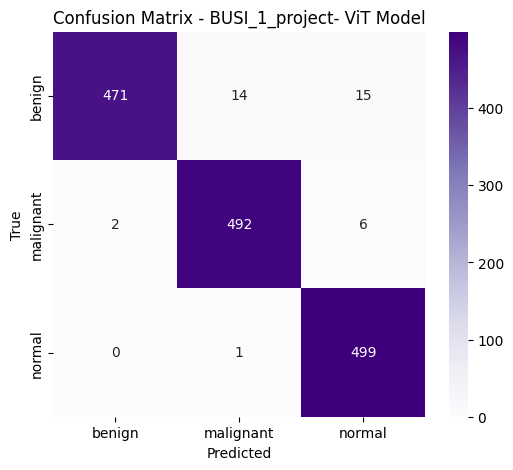

In [ ]:
# Load best model
vit.load_state_dict(torch.load(best_model_path))
vit.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = vit(imgs)
        _, preds = torch.max(out, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification Report
print("📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=train_ds.classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.title("Confusion Matrix - BUSI_1_project- ViT Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



In [ ]:
from google.colab import files

files.download("/content/gdrive/MyDrive/BUSI_1_project/models/best_resnet101.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("/content/gdrive/MyDrive/BUSI_1_project/models/best_vit.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>